## Classical Brute-Force Search vs. Grover’s Predicted Runtime
### **Prepared by: Advay Tyayi 25BCE5574**

This analysis compares how long a **classical linear search** takes versus the **theoretical runtime** predicted by **Grover’s Algorithm**.

### 🔍 What the Code Does
For each problem size defined by  
\[
N = 2^n,\quad n \in \{8,10,12,14,16,18,20\},
\]  
the following steps are performed:

1. **Classical Search Simulation**  
   - A list of size \(N\) is generated.  
   - A random target index is selected.  
   - A brute-force search scans the list until the target is found.  
   - This is repeated **5 trials** per size.  
   - We measure:
     - Average time (in seconds)  
     - Average number of comparisons  

   Classical search scales as:
   \[
   O(N)
   \]

2. **Grover Runtime Estimation**  
   For the same database size \(N\), Grover’s algorithm needs:
   \[
   \frac{\pi}{4}\sqrt{N}
   \]
   oracle calls.  
   By multiplying this by the observed classical **time per comparison**, we estimate:
   - Predicted Grover runtime (ideal noise-free model)

This gives an approximate comparison of classical vs quantum scaling.

---

## 📄 Tabular Comparison
The printed DataFrame shows, for each bit-size:

- `n_bits` — number of qubits  
- `N` — database size  
- `classical_mean_time_s` — average brute-force search time  
- `classical_mean_comparisons` — average comparisons  
- `grover_est_oracle_calls` — theoretical Grover iterations  
- `predicted_grover_time_s` — estimated Grover runtime  

This table summarizes how classical time grows linearly while Grover grows only with \( \sqrt{N} \).

---

## 📈 Plot Explanation

The log–log plot visualizes the scaling behavior:

### 🔵 **Classical (measured)**  
- Actual measured time from brute-force search  
- Appears as a line with slope ~1 on the log-log graph  
- Confirms **O(N)** behavior

### 🟠 **Grover (predicted)**  
- Estimated Grover runtime  
- Grows much more slowly  
- Appears as a line with slope ~0.5  
- Matches **O(√N)** scaling

### Reference Lines  
We include two dashed reference lines:

- **O(N)** — linear classical scaling  
- **O(√N)** — quantum search scaling  

These help visually confirm that:
- Measured classical results follow the O(N) reference  
- Predicted Grover results follow the O(√N) reference  

---

## 🎯 Conclusion

This analysis clearly demonstrates the advantage of Grover’s Algorithm:

- Classical search time grows **too quickly** as database size increases  
- Grover’s predicted runtime grows **much slower**, offering a theoretical quadratic speedup  

Although the Grover curve shown here is based on *ideal mathematical predictions*, the plot effectively visualizes why Grover’s algorithm is significantly faster for large search spaces.





=== Classical Brute Force v/s Grover Speedup Results ===

 n_bits       N  classical_mean_time_s  classical_mean_comparisons  grover_est_oracle_calls  predicted_grover_time_s
      8     256               0.000052                       180.8                12.566371                 0.000004
     10    1024               0.000096                       445.2                25.132741                 0.000005
     12    4096               0.000579                      2721.0                50.265482                 0.000011
     14   16384               0.002126                      9150.0               100.530965                 0.000023
     16   65536               0.007903                     35851.0               201.061930                 0.000044
     18  262144               0.049922                    228863.6               402.123860                 0.000088
     20 1048576               0.118493                    538988.6               804.247719                 0.000177


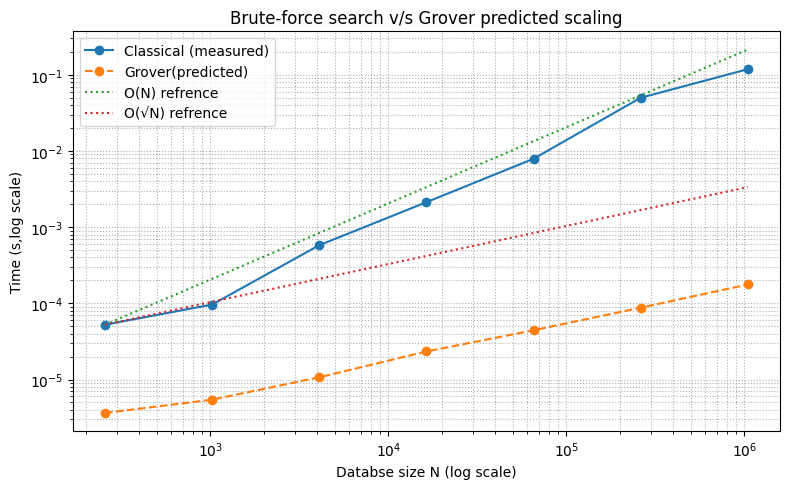

In [3]:
import time,math,random,statistics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

bit_sizes = [8,10,12,14,16,18,20]
trials_per_size = 5
result = []
for n in bit_sizes:
    N = 2**n
    arr = list(range(N))
    times,comps = [],[]
    for _ in range(trials_per_size):
        target = random.randrange(N)
        t0 = time.perf_counter()
        comp = 0
        for i,v in enumerate(arr):
            comp+=1
            if v == target:
                break
        times.append(time.perf_counter()-t0)
        comps.append(comp)
    mean_time = statistics.mean(times)
    mean_comp = statistics.mean(comps)
    times_per_comp = mean_time / mean_comp
    grover_calls = math.pi/4 * math.sqrt(N)
    predicted_grover_time = grover_calls * times_per_comp
    result.append({
    "n_bits":n,
    "N":N,
    "classical_mean_time_s":mean_time,
    "classical_mean_comparisons": mean_comp,
    "grover_est_oracle_calls": grover_calls,
    "predicted_grover_time_s": predicted_grover_time
    })

df = pd.DataFrame(result)
df_rounded = df.round(6)

print("\n=== Classical Brute Force v/s Grover Speedup Results ===\n")
print(df.round(6).to_string(index=False ))

plt.figure(figsize=(8,5))
plt.loglog(df["N"], df["classical_mean_time_s"], marker='o', label='Classical (measured)')
plt.loglog(df["N"], df["predicted_grover_time_s"], marker='o', linestyle='--', label='Grover(predicted)')

Nvals = np.array(df["N"], dtype=float)
lin_factor = df["classical_mean_time_s"].iloc[0]/(Nvals[0])
sqrt_factor = df["classical_mean_time_s"].iloc[0]/math.sqrt(Nvals[0])
plt.loglog(Nvals,lin_factor*Nvals,linestyle=':',label='O(N) refrence')
plt.loglog(Nvals,sqrt_factor*np.sqrt(Nvals),linestyle=':',label='O(√N) refrence')

plt.xlabel("Databse size N (log scale)")
plt.ylabel("Time (s,log scale)")
plt.title("Brute-force search v/s Grover predicted scaling")
plt.legend()
plt.grid(True, which="both",ls=":")
plt.tight_layout()
plt.show()
